# 자기회귀과정 모델링

MA(q) 프로세스:
- 현잿값이 현재 오차 항과 과거 오차 항에 선형적으로 의존.
- q 단계 이상의 미래를 예측하고자 했으나, 데이터 집합에서 오차 항을 확인할 수 없었음. 
- 재귀적으로만 추정할 수 있는 경우, 예측 결과로서 수열의 **평균값**만 얻을 수 있을 뿐.
- ACF 도식을 확인해 정상적 MA(q) 차수를 결정함.
    - 자기상관계수는 lag q 까지만 유의할 것이라는 한계.
    - **다만**, 자기상관계수가 천천히 감소하거나 사인 곡선 패턴을 보이는 경우, 자기회귀과정이 내제되어 있을 수 있음.


이번 챕터 다룰 내용:
- 자기회귀과정
- 편자기상관함수 (partial autocorrelation function; PACF) & 데이터 집합에 내재된 자기회귀과정의 차수를 찾아봄.
- AR(p) 모델을 활용해 예측을 수행.

# 5.1 소매점의 주간 평균 유동인구 예측

많은 사람이 방문 할 예정이면 직원을 늘리고, 방문객이 적으면 직원을 감축하고

In [ ]:
import pandas as pd
#file name: foot_traffic.csv
df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/refs/heads/master/data/foot_traffic.csv')

df.head()
#시간 단위: 주단위

,foot_traffic
0,500.496714
1,500.522366
2,501.426876
3,503.295990
4,504.132695


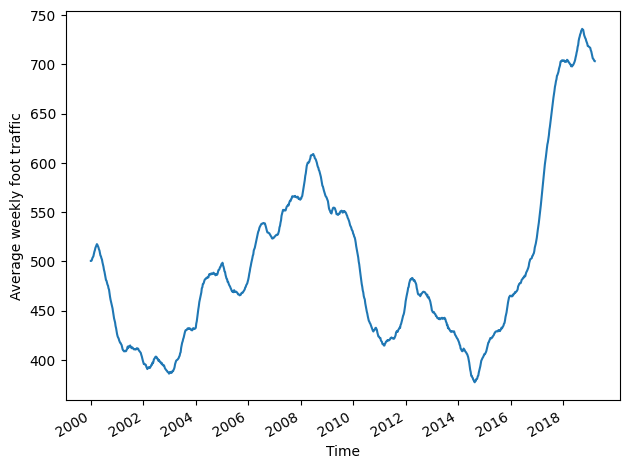

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

ax.plot(df['foot_traffic'])
ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic')

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))
# 0~1000전까지 104 간격으로 숫자 생성
# 데이터가 주 단위라면, 1년 = 52주; 104 = 2년치
# 2년마다 눈금을 찍겠다.

# 2000~2020까지 2씩 증가

fig.autofmt_xdate()
plt.tight_layout()

주간 평균 유동인구를 예측하려면 기반 프로세스를 파악해야 함.
 - 확률보행인지, 이동평균과정인지 확인.

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(df['foot_traffic'])

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -1.1758885999240718
p-value: 0.6838808917896202


# 5.2 자기회귀과정 정의
- 예측값이 이전 값에만 선형적으로 의존한다고 가정.
    - **변수가 자기 자신에게 회귀하는 것.**

AR(p); p = 차수

현잿값 $y_t$는 $\underline{상수\ C}$, 백색소음은 $\underline{현재\ 오차\ 항\ \epsilon_t}, 수열\ y_{t-p}$의 과것값들의 선형 방정식으로 표현.

과것값이 현잿값에 미치는 영향의 크기: $\phi_p$로 표시; AR(p) 모델의 계수

$$y_t = C + \phi_{1} y_{t-1}+\phi_{2}y_{t-2}+...+\phi_{p}y_{t-p} + \epsilon_t$$

이동평균과정 (MA(q))와 마찬가지로, p는 현잿값에 영향을 미치는 과것값들의 개수를 결정.
- ex) AR(1) (1차 자기회귀과정)은 </br>
$y_t = C + \phi_{1}y_{t-1}+\epsilon_t$

만약 $\phi_1 = 1$일 경우: $y_t=C+y_{t-1}+\epsilon_t$ --> 확률보행 모델
- p가 1이고 $\phi_1$은 1인 자기회귀과정의 특수한 경우



# 5.3 정상적 자기회귀과정의 차수 찾기
- lag p 이후 계수가 갑자기 유의하지 않게 되는가?
    - YES: AR(p) 프로세스.
    - NO: AR(p) 프로세스가 아님.

In [4]:
# 윗 ADF Test에 이어서
# ADF 테스트 결과에 기반하여, 수열은 비정상적

# Transform
# 추세 효과 제거 및 수열의 평균을 안정화

import numpy as np
foot_traffic_diff = np.diff(df['foot_traffic'], n=1)

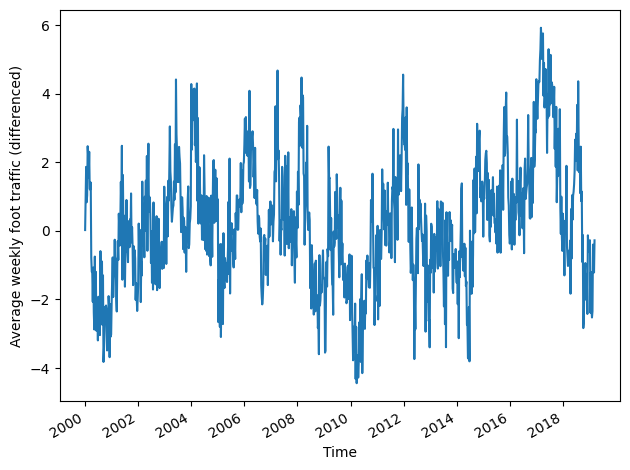

In [5]:
fig, ax = plt.subplots()

ax.plot(foot_traffic_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic (differenced)')

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()

In [6]:
# ADF after transform

ADF_result = adfuller(foot_traffic_diff)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -5.268231347422036
p-value: 6.369317654781499e-06


Interpretation:
- it's stationary after differencing

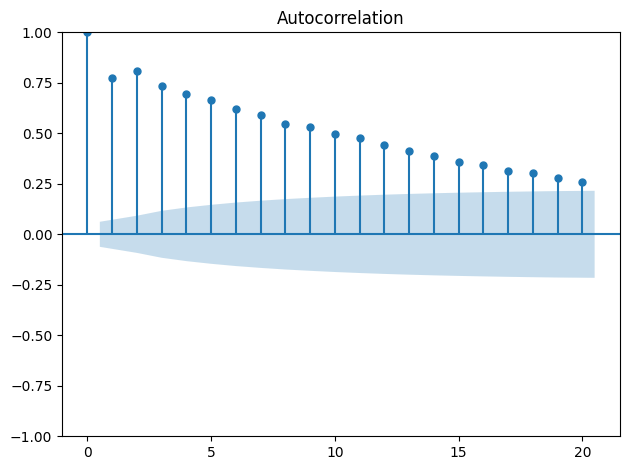

In [7]:
# ACF Visualization

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(foot_traffic_diff, lags = 20)

plt.tight_layout()

Interpretation:
- lag 0 이후 유의한 자기상관계수가 있으므로 확률보행이 아님
- 지연이 증가함에 따라 계수가 급하게 감소 --> 계수가 갑자기 유의하지 **않게 되는** 어떤 지연값이 $\underline{존재하지\ 않음}$.
- **이동평균 없고, 자기회귀과정이 내재되어 있을 가능성이 높다.**

<p align="center">그럼 차수 p를 어떻게 식별하는가?</p>

## 5.3.1 편자기상관함수 (Partial Autocorrelation Function; PACF)
- 자기상관함수: 지연이 증가함에 따라 두 값 사이의 상관관계가 어떻게 변하는지를 측정

$y_t$가 $y_{t-2}$와 어떻게 관련이 되어있는가?

예시)
</br>
$y_t = 0.33y_{t-1}+0.5y_{t-2}$
- AR(2) 프로세스이기에, $y_t$는 $y_{t-1}과 y_{t-2}$에 영향을 받음.
- ACF를 사용해 $y_t$와 $y_{t-2}$ 사이의 자기상관관계만 측정한다면, $y_{t-1}$이 $y_{t}$와 $y_{t-2}$ 둘 다에 영향을 미친다는 점을 고려하지 않은 것.
    - **즉, $y_{t-2}$가 $y_{t}$에 미치는 영향을 적확하게 측정하지 못함.**
<div align="center">

$y_t$와 $y_{t-2}$ 사이의 <b>편자기상관관계(partial autocorrelation)</b>를 측정해야 함.

</div>

편자기상관관계는 시계열 내에서 $\underline{지연된\ 값들\ 간의\ 상관관계}$를 측정. 
- lag 간의 상관관계 측정?
- 상관관계가 있는 지연된 값들 간의 영향도를 제거할 때 사용하거나, 제거 결과를 확인할 때 사용.
- 이러한 상관관계가 있는 값들은 **교란 변수 (confounding variable)** 이라 부름.
- PACF를 도식화 후 정상화된 AR(p) 프로세스의 차수를 결정할 수 있음. 지연 p는 그 이후 계수들이 유의하지 않은 값.

In [8]:
#예시로 활동
# AR(2) 프로세스
# AR(2) 프로세스만 시뮬레이션 할것이므로 MA(q) 프로세스의 계수들은 0으로 설정.

from statsmodels.tsa.arima_process import ArmaProcess

np.random.seed(42)

ma2 = np.array([1,0,0])
ar2 = np.array([1, -0.33, -0.5]) #AR 계수들은 원래 부호와 반대로 지정; 1 = 지연0의 계수

AR2_process = ArmaProcess(ar2, ma2).generate_sample(nsample = 1000) #AR(2) 프로세스를 시뮬레이션해 1000개의 샘플을 생성

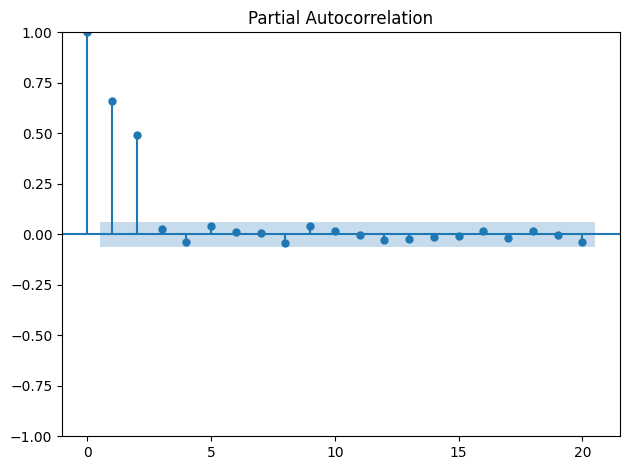

In [11]:
# 이제 시뮬레이션된 AR(2) 프로세스를 얻었으므로, PACF 도식화하고 지연2 이후에 계수들이 유의하지 않게 되는지 확인.
# 가정이 맞다면 ACF 도식으로 정상적 이동평균과정의 차수를 결정할 수 있는것과 같이, PACF 도식으로 정상적 자기회귀과정의 차수도 결정.

from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(AR2_process, lags = 20)
plt.tight_layout()

Interpretation:
- 계수는 지연 p까지 유의, 그 이후는 0에 가까움.

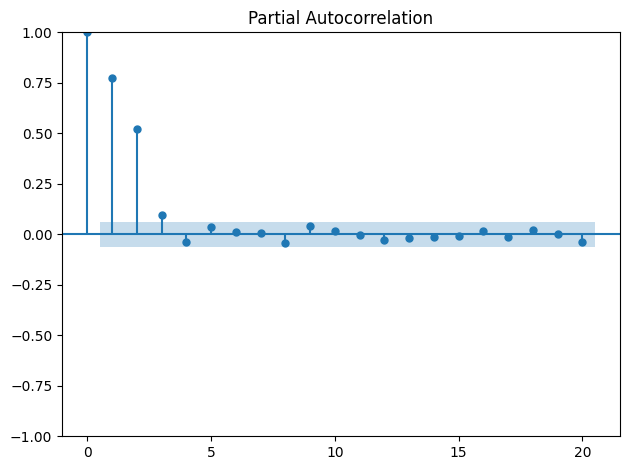

In [12]:
# 다시 돌아와 foot_traffic 데이터로

plot_pacf(foot_traffic_diff, lags=20)
plt.tight_layout()

Interpretation:
- 지연 3 이후에는 유의한 계수 없음
    - 차분된 주간 평균 유동 인구는 AR(3)

# 5.4 자기회귀과정 예측

차수를 결정하고 나면 자기회귀 모델을 피팅하여 시계열 에측 가능.

In [ ]:
df_diff = pd.DataFrame({'foot_traffic_diff': foot_traffic_diff})

train = df_diff[:-52] # 뒤에서 52개를 제외한 전부
test = df_diff[-52:] # 뒤에서 52개

print(len(train))
print(len(test))

947
52


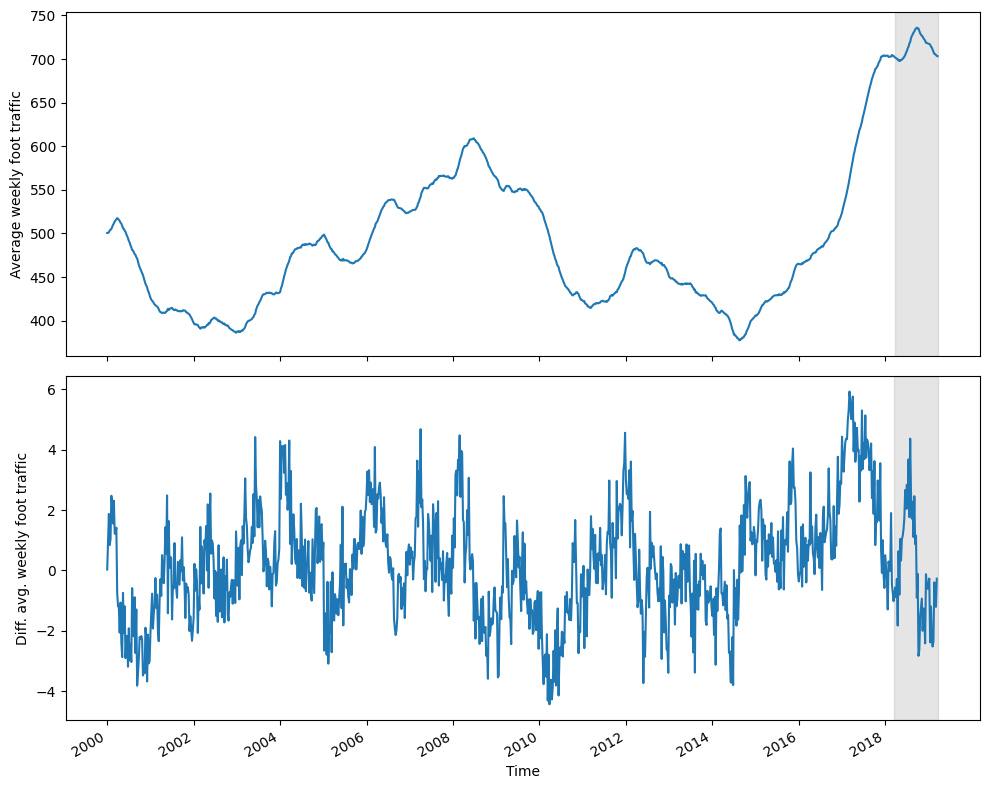

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 8))

ax1.plot(df['foot_traffic'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Average weekly foot traffic')
ax1.axvspan(948, 1000, color='#808080', alpha=0.2)

ax2.plot(df_diff['foot_traffic_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Diff. avg. weekly foot traffic')
ax2.axvspan(947, 999, color='#808080', alpha=0.2) 
# why not from 948?
# - differenced data: 947/52
# REMEMBER: after differencing, the lost data is the most front data

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()